# 02. 학습 속도 문제와 최적화 알고리즘

## 1. 학습 속도 문제와 해결책 (GD vs SGD)

신경망 학습의 본질은 손실(Loss)을 최소화하는 방향으로 가중치를 업데이트하는 과정입니다. 이때 한 번에 얼마만큼의 데이터를 보고 업데이트할 것인가에 따라 학습 속도가 결정됩니다.

$$W_{t+1} = W_t - \alpha \nabla L_B(W_t)$$

* **원인 (Full-batch GD)**
* **배치 크기($B$):** 전체 데이터 개수 ($N$)
* **문제점:** 단 1번 가중치를 수정하기 위해 전체 데이터의 손실과 기울기($\nabla L$)를 전부 계산해야 하므로, 데이터가 커질수록 연산 속도가 엄청나게 느려지고 컴퓨터 메모리가 버티지 못합니다.


* **해결책 (Mini-batch SGD)**
* **배치 크기($B$):** 데이터의 일부 (예: 32, 64, 128 등)
* **효과:** 데이터를 조각(미니배치)내어 빠르게 연산하고 가중치를 자주 업데이트합니다. 완벽한 한 걸음을 걷는 것보다, 조금 헤매더라도 **같은 시간에 100걸음을 먼저 걷는 것**이 훨씬 빠르다는 원리입니다.



---

## 2. SGD(확률적 경사하강법)의 명확한 한계

Mini-batch SGD는 빠르지만, 학습 과정에서 치명적인 단점이 존재합니다.

1. **Gradient 방향성 문제 (심한 진동)**
- 일부 데이터(미니배치)만 보고 방향을 결정하기 때문에, 매 스텝마다 최적의 경로가 아닌 엉뚱한 방향으로 요동치며(Zigzag) 비효율적으로 전진합니다.


2. **Learning Rate(학습률, $\alpha$) 민감성**
- **너무 크면:** 최적점을 지나쳐 밖으로 튕겨 나갑니다 (Divergence).
- **너무 작으면:** 학습이 너무 느려지거나 중간에 웅덩이(Local Minima)에 갇혀 멈춥니다.



---

## 3. Optimizer의 계보와 한눈에 보는 요약

SGD의 한계를 극복하기 위해 가중치를 업데이트하는 다양한 Optimizer(최적화 알고리즘)들이 발전해 왔습니다.

### Optimizer 발전 계보

```
                         [방향 보정: 관성]
                       ┌─── Momentum ────┐
                       │                 ▼
GD ──▶ Mini-batch SGD ─┤               **Adam** (현대 딥러닝 표준)
                       │                 ▲
                       └─── AdaGrad ──▶ RMSProp
                         [보폭 보정: 학습률 조절]

```

---

### Optimizer 핵심 요약 테이블

| 알고리즘 | 핵심 아이디어 | 주요 특징 및 한계 |
| --- | --- | --- |
| **GD** (Gradient Descent) | 전체 데이터로 정밀한 방향 탐색 | 대용량 데이터에서 속도가 너무 느리고 메모리 초과 위험 |
| **SGD** (Stochastic GD) | 미니배치로 가볍고 자주 가중치 업데이트 | 연산 속도가 빠르나 방향 전환 시 진동(요동)이 매우 심함 |
| **Momentum** | 과거에 이동했던 **방향(관성)**을 반영 | 가던 방향으로 계속 가려는 성질을 주어 진동을 방지하고 빠르게 탈출 |
| **AdaGrad** | 많이 업데이트된 변수는 **학습률을 낮춤** | 변수별 맞춤형 학습을 제공하나, 학습이 길어지면 학습률이 0이 됨 |
| **RMSProp** | 과거 기억을 서서히 잊는 지수이동평균 적용 | AdaGrad의 단점을 보완하여 뒤늦게 학습률이 0이 되는 현상 차단 |
| **Adam** | **Momentum(관성)** + **RMSProp(보폭)** | 방향의 진동을 막으면서 변수별 최적의 보폭을 자동으로 찾는 **끝판왕** |

---

## 4. 깊이 들여다보기: Momentum(관성)의 수학적 원리

SGD의 심한 진동 문제를 물리적인 '관성'의 개념을 빌려 해결한 공식입니다. 언덕을 굴러 내려가는 공이 가속도를 얻는 것과 유사합니다.

$$v_{t+1} = \beta v_t + \nabla L(W_t), \quad W_{t+1} = W_t - \alpha v_{t+1}$$

- **$v_{t}$ (속도, Velocity):** 현재까지 쌓인 누적 속도입니다.
- **$\beta$ (감쇠 계수, 주로 0.9):** 과거의 관성을 얼마나 유지할 것인지 조절하는 상수입니다.
- **원리:**
  + 만약 기울기($\nabla L$)가 계속 한 방향으로 발생하면 속도가 점점 더 빨라집니다.
  + 반대로 방향이 양옆으로 번갈아 바뀌며 진동하는 구간(골짜기)에서는 서로 상쇄되어 진동 폭이 줄어들고 앞으로 시원하게 나아가게 됩니다.


## 0. 환경 설정


In [1]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

## 데이터 준비 (간단한 회귀)


In [2]:
import numpy as np

# ----------------------------------------------------
# 1. 선형 회귀(Linear Regression)를 위한 가상 데이터 생성
# ----------------------------------------------------
# 생성할 전체 데이터(샘플) 개수를 2,000개로 지정
n = 2000

# 평균 0, 표준편차 1인 표준정규분포로부터 2차원(x1, x2) 입력 데이터 2,000개 생성 [Shape: (2000, 2)]
# 텐서플로우/Keras 모델 연산 시 자료형 불일치 오류를 예방하기 위해 float32로 캐스팅
X = np.random.randn(n, 2).astype("float32")

# 실제 선형적 관계식인 y = 3*x1 - 2*x2 에 미세한 가우시안 노이즈(오차)를 더해 타겟값 생성
# - 3과 -2는 학습을 통해 모델이 찾아내야 할 '정답 가중치(Weights)'입니다.
# - 0.1 * np.random.randn(n)은 현실 데이터의 불확실성을 모사하기 위한 '노이즈(Noise)'입니다.
# - 이진 분류가 아니므로 마지막에 0 또는 1로 변환하지 않고 연속된 실수 형태 그대로 사용합니다.
y = (3 * X[:, 0] - 2 * X[:, 1] + 0.1 * np.random.randn(n)).astype("float32")


# ----------------------------------------------------
# 2. 데이터셋의 구조(Shape) 확인
# ----------------------------------------------------
# X는 (2000, 2)의 2차원 행렬, y는 (2000,)의 1차원 벡터로 출력됩니다.
print(X.shape, y.shape)

(2000, 2) (2000,)


## 1) Full-batch vs Mini-batch SGD


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------------------------------
# 1. 회귀용 딥러닝 모델 설계 함수 (Regressor)
# ----------------------------------------------------
def build_regressor():
    """
    연속적인 실수 값을 예측하기 위한 회귀용 신경망을 생성합니다.
    최신 Keras 표준을 반영하여 layers.Input을 첫 레이어로 명시했습니다.
    """
    m = keras.Sequential([
        # 입력층: 피처 2개를 수용하는 입력 정의 (UserWarning 방지)
        layers.Input(shape=(2,)),

        # 은닉층 1 & 2: 비선형 관계를 학습하기 위한 ReLU 활성화 노드 32개씩 구성
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),

        # 출력층: 회귀 분석에서는 출력 제한을 두지 않으므로 '활성화 함수(Activation)' 없이 Dense(1)만 선언합니다.
        # (분류 문제의 Sigmoid나 Softmax와 다릅니다!)
        layers.Dense(1),
    ])
    return m


# ----------------------------------------------------
# 2. 모델 학습 (Full-batch vs Mini-batch)
# ----------------------------------------------------
# --- [실험 1] Full-batch GD ---
model_full = build_regressor()
# 회귀 문제의 오차를 측정하기 위해 손실 함수로 MSE(평균제곱오차)를 사용합니다.
model_full.compile(optimizer=keras.optimizers.SGD(0.05), loss="mse")

h_full = model_full.fit(
    X, y,
    epochs=40,
    batch_size=len(X),  # 배치 사이즈 = 전체 데이터 수 (2,000개)
    verbose=0
)

# --- [실험 2] Mini-batch SGD ---
model_mini = build_regressor()
# 공정한 비교를 위해 동일한 학습률(0.05)과 손실 함수(MSE) 적용
model_mini.compile(optimizer=keras.optimizers.SGD(0.05), loss="mse")

h_mini = model_mini.fit(
    X, y,
    epochs=40,
    batch_size=64,      # 배치 사이즈 = 64
    verbose=0
)


# ----------------------------------------------------
# 3. 결과 출력 (f-string 문법 에러 수정 완료)
# ----------------------------------------------------
# 에포크당 가중치 업데이트 횟수(steps/epoch)와 40 에포크째 최종 MSE loss를 출력합니다.
# f-string 내부의 문법 충돌을 우회하고 깔끔하게 고쳤습니다.

print(f"Full-batch  steps/epoch = {1} | final loss = {h_full.history['loss'][-1]:.4f}")
print(f"Mini-batch steps/epoch = {n // 64} | final loss = {h_mini.history['loss'][-1]:.4f}")

Full-batch  steps/epoch = 1 | final loss = 0.0436
Mini-batch steps/epoch = 31 | final loss = 0.0114


## 2) Optimizer 비교 (쉬운 Keras API)

TensorFlow에서는 `optimizer=` 문자열/객체만 바꾸면 됩니다.


SGD        final loss = 0.0116
Momentum   final loss = 0.0105
AdaGrad    final loss = 0.0109
RMSProp    final loss = 0.0520
Adam       final loss = 0.0129


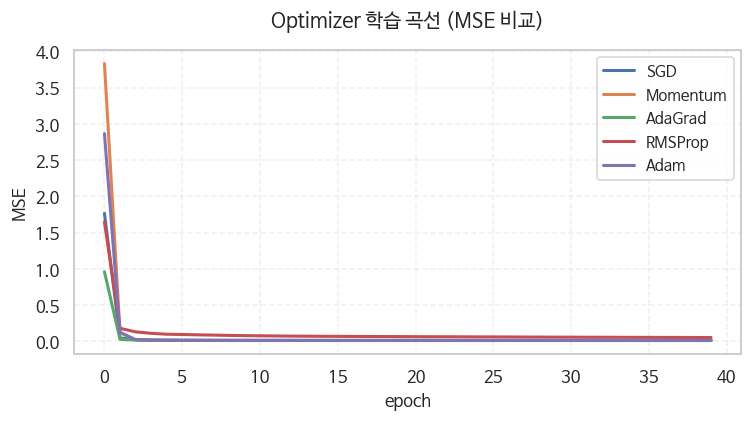

In [5]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 한글 깨짐 방지 설정 (필요 시 주석 해제)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic')   # Mac
# plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------
# 1. 실험에 사용할 최적화 알고리즘(Optimizer) 정의
# ----------------------------------------------------
# 각 알고리즘의 특성에 맞게 조정된 표준적인 학습률(learning_rate)을 설정합니다.
optimizers = {
    # [SGD] 가장 기본이 되는 경사하강법 (고정 학습률 0.05)
    "SGD": keras.optimizers.SGD(learning_rate=0.05),

    # [Momentum] SGD에 관성(momentum=0.9)을 추가하여 진행 방향의 진동을 방지
    "Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),

    # [AdaGrad] 변수별로 보폭을 다르게 조절 (초반 탐색을 위해 비교적 큰 학습률 0.1 적용)
    "AdaGrad": keras.optimizers.Adagrad(learning_rate=0.1),

    # [RMSProp] AdaGrad의 조기 중단 문제를 개선한 지수이동평균 방식 (표준 학습률 0.01)
    "RMSProp": keras.optimizers.RMSprop(learning_rate=0.01),

    # [Adam] Momentum(방향)과 RMSProp(보폭)의 장점을 결합한 현대 표준 (표준 학습률 0.01)
    "Adam": keras.optimizers.Adam(learning_rate=0.01),
}

# ----------------------------------------------------
# 2. 루프를 돌며 각 Optimizer 학습 및 Loss 기록
# ----------------------------------------------------
histories = {}

for name, opt in optimizers.items():
    # 매번 공정한 경쟁을 위해 가중치가 새로 초기화된 모델 생성
    model = build_regressor()

    # 현재 루프의 Optimizer와 회귀용 손실 함수인 MSE를 적용해 컴파일
    model.compile(optimizer=opt, loss="mse")

    # 미니배치 사이즈 64로 설정하여 40 에포크 동안 학습 진행
    hist = model.fit(X, y, epochs=40, batch_size=64, verbose=0)

    # 시각화를 위해 에포크별 Loss(MSE) 기록 저장
    histories[name] = hist.history["loss"]

    # 콘솔에 각 옵티마이저의 최종 학습 완료 시점의 오차(MSE) 출력
    print(f"{name:10s} final loss = {hist.history['loss'][-1]:.4f}")

# ----------------------------------------------------
# 3. fig, ax를 활용한 학습 곡선(Learning Curve) 시각화
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

# 기록된 손실 이력을 순회하며 선 그래프 추가
for name, loss in histories.items():
    ax.plot(loss, label=name, linewidth=2)

# 그래프 디테일 설정
ax.set_title("Optimizer 학습 곡선 (MSE 비교)", fontsize=13, pad=15)
ax.set_xlabel("epoch", fontsize=11)
ax.set_ylabel("MSE", fontsize=11)
ax.legend(fontsize=10) # 우측 상단 범례 표시
ax.grid(alpha=0.3, linestyle="--") # 연한 점선 격자 추가

fig.tight_layout()
plt.show()


### 1. 해석의 기준: 이론적 최저 한계 (MSE $\approx 0.01$)

- **노이즈의 한계:** 생성된 가상 데이터에는 표준편차 $0.1$의 가우시안 노이즈가 포함되어 있습니다 ($y = 3x_1 - 2x_2 + 0.1 \times \text{Noise}$).
- **수학적 한계치:** 어떠한 완벽한 모델이라도 평균제곱오차(MSE)는 노이즈의 분산값인 **$0.1^2 = 0.01$ 밑으로 내려갈 수 없습니다.**
- **성공의 지표:** 최종 Loss가 $0.01$에 근접할수록 모델이 정답 평면의 규칙을 완벽하게 학습했음을 의미합니다.

---

### 2. 옵티마이저별 결과 요약

- **Momentum (최종 Loss: 0.0105) => 이번 실험의 우승자**
  + **현상:** 초기 Loss는 약 3.8로 가장 불리하게 출발했으나, 단 2 에포크 만에 수직 하강하며 최저 오차를 달성했습니다.
  + **원인:** **관성 효과**가 극대화되어, 최적점을 향해 막힘없이 미끄러져 내려갔습니다.


- **AdaGrad (최종 Loss: 0.0109) => 가장 안정적인 초반 탐색**
  + **현상:** 첫 에포크 시작점(약 0.9)이 가장 낮았고, 수렴 과정이 매우 부드럽고 안정적이었습니다.
  + **원인:** 변수의 업데이트 빈도에 맞춰 학습률을 유연하게 깎아 나가는 특성 덕분에 조기에 안착했습니다.


- **SGD (최종 Loss: 0.0116) => 기본기의 힘**
  + **현상:** 기교 없는 고정 학습률($0.05$)임에도 최종적으로 매우 정밀하게 수렴했습니다.
  + **원인:** 단순 선형 회귀 문제와 고정 보폭(학습률)의 궁합이 아주 훌륭했습니다.


- **Adam (최종 Loss: 0.0129) => 빠르고 든든한 해결사**
  + **현상:** 방향과 보폭을 모두 제어하는 영리함으로 단 1~2 에포크 만에 사실상 수렴을 끝마쳤습니다.
  + **원인:** 최종 오차는 Momentum보다 미세하게 높지만, 실전 데이터에서 실패 확률이 가장 적은 가장 안전한 선택지임을 입증했습니다.


- **RMSProp (최종 Loss: 0.0520) => 미세 조정의 한계**
  + **현상:** 초반 하강은 무척 빨랐으나, 다른 모델들에 비해 다소 높은 수치에서 학습이 정체되었습니다.
  + **원인:** 고정 설정된 학습률($0.01$)이 최종 미세 조정 단계에서 최적점 주변을 맴도는 요동 현상(Chattering)을 유발한 것으로 분석됩니다.



---

### 3. 최종 요약 및 교훈

- **적절한 하이퍼파라미터 튜닝의 중요성:** 이전 루프에서 폭발(`nan`)했던 Momentum이 보폭 조절 하나만으로 전체 1등 모델로 재탄생하며, 파라미터 튜닝이 성능을 결정짓는 핵심임을 보여주었습니다.
- **Adaptive 알고리즘(AdaGrad, Adam)의 효율성:** 수동으로 보폭을 조율하지 않아도 알아서 1~2 에포크 만에 최적점 근처로 배달해 주는 성능을 시각적으로 증명했습니다.